# Economic Significance V4 - Multi-Asset DCA cu Semnal V5
**Idee:** Modelul V5 detecteaza V-shape pe SP500, dar investim in assets mai volatile

**Assets:** QQQ (Nasdaq 100), IWM (Small Caps), SOXX (Semiconductori)

**Perioada:** Ianuarie 2017 - Aprilie 2026 (9 ani, complet out-of-sample)

**Strategii per asset:**
- DCA Simplu: $100/saptamana mereu
- DCA Accelerat V5: $70 mereu + $30 in cash, deployed in V-shape

## 1. Import si Incarcare Model

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, pickle, os, warnings
warnings.filterwarnings('ignore')
from fredapi import Fred

os.makedirs('plots', exist_ok=True)

ensemble = pickle.load(open('../V5/models/v5_ensemble.pkl', 'rb'))
scaler   = pickle.load(open('../V5/models/v5_scaler.pkl',   'rb'))

with open('../V5/models/v5_model_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS      = meta['feature_cols']
OPTIMAL_THRESHOLD = meta['optimal_threshold']
WEEKLY_BUDGET     = 100
BASE_INVEST       = 70
CASH_SAVE         = 30
T_LOW             = 0.30
T_HIGH            = OPTIMAL_THRESHOLD

ASSETS = {
    'QQQ' : 'Nasdaq 100',
    'IWM' : 'Small Caps (Russell 2000)',
    'SOXX': 'Semiconductori'
}

print('Model:', meta['model_name'], '| AUC:', meta['auc'])
print('Threshold T_HIGH:', T_HIGH, '| T_LOW:', T_LOW)
print('Budget:', WEEKLY_BUDGET, '| Base:', BASE_INVEST, '| Cash:', CASH_SAVE)

Model: Voting Ensemble | AUC: 0.804
Threshold T_HIGH: 0.62 | T_LOW: 0.3
Budget: 100 | Base: 70 | Cash: 30


## 2. FRED API Key

In [2]:
FRED_API_KEY = '9cbb31e1e8aeea0f649895cfc852dce7'
fred = Fred(api_key=FRED_API_KEY)
print('FRED API conectat.')

FRED API conectat.


## 3. Descarcare Date

In [16]:
START_DATA     = '2016-01-01'
START_BACKTEST = '2017-01-01'
END_BACKTEST   = '2026-04-14'

sp500 = yf.download('^GSPC', start=START_DATA, end=END_BACKTEST, auto_adjust=True)
sp500 = sp500[['Close', 'Volume']].copy()
sp500.columns = ['SP500_Close', 'SP500_Volume']

vix = yf.download('^VIX', start=START_DATA, end=END_BACKTEST, auto_adjust=True)
vix = vix[['Close']].copy()
vix.columns = ['VIX_raw']

daily = sp500.join(vix, how='left')
daily.index = pd.to_datetime(daily.index)

asset_data = {}
for ticker, name in ASSETS.items():
    data = yf.download(ticker, start=START_DATA, end=END_BACKTEST, auto_adjust=True)
    asset_data[ticker] = data['Close'].copy()
    print(ticker.ljust(6), '|', name.ljust(28),
          '| Start:', data.index[0].date(),
          '| Ultima val: $' + str(round(float(data['Close'].iloc[-1]), 2)))

FALLBACK_VALUES = {
    'Yield_Curve': 0.50, 'Jobless_Claims': 300000,
    'Credit_Spread': 3.50, 'Dollar_Index': 90.0, 'Fed_Rate': 2.50
}
fred_series = {
    'Yield_Curve'   : ['T10Y2Y', 'T10Y3M', 'DGS10'],
    'Jobless_Claims': ['ICSA', 'IC4WSA'],
    'Credit_Spread' : ['BAMLH0A0HYM2', 'BAMLC0A0CBBB'],
    'Dollar_Index'  : ['DTWEXM', 'DTWEXBGS'],
    'Fed_Rate'      : ['FEDFUNDS', 'DFF', 'DFEDTARU']
}

macro_raw = pd.DataFrame()
for name, codes in fred_series.items():
    success = False
    for code in codes:
        try:
            series = fred.get_series(code, observation_start=START_DATA, observation_end=END_BACKTEST)
            if series.dropna().empty:
                continue
            series.name = name
            macro_raw = macro_raw.join(series, how='outer') if not macro_raw.empty else series.to_frame()
            print(name.ljust(20), '| OK:', code)
            success = True
            break
        except:
            continue
    if not success:
        macro_raw[name] = FALLBACK_VALUES.get(name, 0.0)
        print(name.ljust(20), '| FALLBACK')

macro_raw.index = pd.to_datetime(macro_raw.index)
macro_raw = macro_raw.ffill().bfill()
print('\nDate descarcate.')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


QQQ    | Nasdaq 100                   | Start: 2016-01-04 | Ultima val: $617.39
IWM    | Small Caps (Russell 2000)    | Start: 2016-01-04 | Ultima val: $265.07
SOXX   | Semiconductori               | Start: 2016-01-04 | Ultima val: $393.34
Yield_Curve          | OK: T10Y2Y
Jobless_Claims       | OK: ICSA
Credit_Spread        | OK: BAMLH0A0HYM2
Dollar_Index         | OK: DTWEXM
Fed_Rate             | OK: FEDFUNDS

Date descarcate.


## 4. Feature Engineering + Semnal V5

In [17]:
df = daily.join(macro_raw, how='left').ffill().bfill()

df['MA50']             = df['SP500_Close'].rolling(50).mean()
df['MA200']            = df['SP500_Close'].rolling(200).mean()
df['Dist_MA50']        = (df['SP500_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200']       = (df['SP500_Close'] - df['MA200']) / df['MA200']
df['Dist_52w_High']    = (df['SP500_Close'] - df['SP500_Close'].rolling(252).max()) / df['SP500_Close'].rolling(252).max()
df['Return_1d']        = df['SP500_Close'].pct_change()
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)
df['Local_Min_20d']    = df['SP500_Close'].rolling(20).min()
df['Dist_Local_Min']   = (df['SP500_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']
df['VIX_MA60']         = df['VIX_raw'].rolling(60).mean()
df['VIX_Ratio']        = df['VIX_raw'] / df['VIX_MA60']

delta = df['SP500_Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))

def rolling_slope(series, window):
    slopes = [np.nan] * len(series)
    vals, x = series.values, np.arange(window)
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

df['VIX_Trend_20d']      = rolling_slope(df['VIX_raw'], 20)
df['SP500_Trend_20d']    = rolling_slope(df['SP500_Close'], 20)
df['Yield_Curve_Change'] = df['Yield_Curve'].diff(20)
df['Jobless_MA12']       = df['Jobless_Claims'].rolling(60).mean()
df['Jobless_Ratio']      = df['Jobless_Claims'] / df['Jobless_MA12']
df['Dollar_Change']      = df['Dollar_Index'].pct_change(4).fillna(0.0)

agg_rules = {
    'SP500_Close': 'last', 'SP500_Volume': 'sum', 'VIX_raw': 'mean',
    'Dist_MA50': 'last', 'Dist_MA200': 'last', 'Dist_52w_High': 'last',
    'RSI': 'last', 'Dist_Local_Min': 'last', 'VIX_Ratio': 'mean',
    'VIX_Trend_20d': 'mean', 'SP500_Trend_20d': 'last',
    'Realized_Vol_10d': 'mean', 'Yield_Curve': 'mean',
    'Yield_Curve_Change': 'last', 'Jobless_Ratio': 'mean', 'Dollar_Change': 'last'
}
for col in ['Credit_Spread', 'Fed_Rate']:
    if col in df.columns:
        agg_rules[col] = 'mean' if col == 'Credit_Spread' else 'last'

weekly = df.resample('W-FRI').agg(agg_rules)
weekly = weekly.rename(columns={'VIX_raw': 'VIX'})
weekly['Return_1w']    = weekly['SP500_Close'].pct_change()
weekly['Return_4w']    = weekly['SP500_Close'].pct_change(4)
weekly['Volume_Ratio'] = weekly['SP500_Volume'] / weekly['SP500_Volume'].rolling(8).mean()
weekly = weekly.loc[:, ~weekly.columns.duplicated()]
for col, val in [('Credit_Spread', 3.50), ('Fed_Rate', 2.50)]:
    if col not in weekly.columns:
        weekly[col] = val
weekly = weekly.ffill()
weekly.dropna(subset=['Return_1w'], inplace=True)

weekly_bt = weekly[weekly.index >= START_BACKTEST].copy()
weekly_bt['Phase'] = 1

X_bt = pd.DataFrame(
    np.zeros((len(weekly_bt), len(FEATURE_COLS))),
    columns=FEATURE_COLS, index=weekly_bt.index
)
for col in FEATURE_COLS:
    if col in weekly_bt.columns:
        X_bt[col] = weekly_bt[col].fillna(0.0).values

proba   = ensemble.predict_proba(scaler.transform(X_bt.values))[:, 1]
proba_s = pd.Series(proba, index=weekly_bt.index).shift(1).fillna(0)
tbill_w = (weekly_bt.get('Fed_Rate', pd.Series(2.5, index=weekly_bt.index)) / 100 / 52).values

n_weeks  = len(weekly_bt)
pct_high = round((proba_s >= T_HIGH).mean() * 100, 1)
pct_mid  = round(((proba_s >= T_LOW) & (proba_s < T_HIGH)).mean() * 100, 1)
pct_low  = round((proba_s < T_LOW).mean() * 100, 1)

print('Saptamani backtest:', n_weeks)
print('Semnal puternic V-shape (P>', str(T_HIGH) + '):', pct_high, '%')
print('Semnal moderat (' + str(T_LOW) + '-' + str(T_HIGH) + '):', pct_mid, '%')
print('Semnal slab (P<' + str(T_LOW) + '):', pct_low, '%')

Saptamani backtest: 485
Semnal puternic V-shape (P> 0.62): 7.0 %
Semnal moderat (0.3-0.62): 15.7 %
Semnal slab (P<0.3): 77.3 %


## 5. Simulare DCA per Asset

In [10]:
# DEBUG - rulează asta înainte de run_dca
print(type(T_HIGH), T_HIGH)
print(type(T_LOW), T_LOW)
print(type(tbill_w), tbill_w.dtype)
print(type(proba_s), proba_s.dtype)

<class 'float'> 0.62
<class 'float'> 0.4
<class 'numpy.ndarray'> float64
<class 'pandas.core.series.Series'> float64


In [18]:
def run_dca(prices_weekly, proba_s, tbill_w, mode='simple'):
    shares, cash, total_inv = 0.0, 0.0, 0.0
    shares_log, value_log, cash_log = [], [], []

    t_high = float(T_HIGH)
    t_low  = float(T_LOW)
    prices_weekly = prices_weekly.squeeze()  # ← forțăm Series dacă e DataFrame cu o coloană

    for i in range(len(prices_weekly)):
        p  = float(proba_s.iloc[i])
        px = float(prices_weekly.iloc[i]) if not pd.isna(prices_weekly.iloc[i]) else 0.0
        if px <= 0:
            shares_log.append(shares)
            value_log.append(shares * px + cash)
            cash_log.append(cash)
            continue
        if mode == 'simple':
            shares    += WEEKLY_BUDGET / px
            total_inv += WEEKLY_BUDGET
        elif mode == 'accelerated':
            shares    += BASE_INVEST / px
            if p >= t_high:
                deploy  = CASH_SAVE + cash
                shares += deploy / px
                cash    = 0.0
            elif p >= t_low:
                shares += CASH_SAVE / px
            else:
                cash   += CASH_SAVE
                cash   *= (1 + float(tbill_w[i]))
            total_inv += WEEKLY_BUDGET
        shares_log.append(shares)
        value_log.append(shares * px + cash)
        cash_log.append(cash)
    return {
        'shares'    : shares,
        'cash'      : cash,
        'total_inv' : total_inv,
        'final_val' : shares * float(prices_weekly.iloc[-1]) + cash,
        'avg_cost'  : (total_inv - cash) / shares if shares > 0 else 0,
        'shares_log': pd.Series(shares_log, index=prices_weekly.index),
        'value_log' : pd.Series(value_log,  index=prices_weekly.index),
        'cash_log'  : pd.Series(cash_log,   index=prices_weekly.index)
    }

results_all = {}
for ticker, name in ASSETS.items():
    asset_weekly = asset_data[ticker].resample('W-FRI').last()
    asset_weekly = asset_weekly[asset_weekly.index >= START_BACKTEST]
    asset_weekly = asset_weekly.reindex(weekly_bt.index, method='ffill')
    dca = run_dca(asset_weekly, proba_s, tbill_w, mode='simple')
    acc = run_dca(asset_weekly, proba_s, tbill_w, mode='accelerated')
    results_all[ticker] = {'dca': dca, 'acc': acc, 'name': name}
    dca_ret = round((dca['final_val'] - dca['total_inv']) / dca['total_inv'] * 100, 2)
    acc_ret = round((acc['final_val'] - acc['total_inv']) / acc['total_inv'] * 100, 2)
    print(ticker, '|', name)
    print('  DCA Simplu:    Shares:', round(dca['shares'],4),
          '| Val: $' + str(round(dca['final_val'],0)),
          '| Return:', str(dca_ret) + '%',
          '| Cost/share: $' + str(round(dca['avg_cost'],2)))
    print('  DCA Accelerat: Shares:', round(acc['shares'],4),
          '| Val: $' + str(round(acc['final_val'],0)),
          '| Return:', str(acc_ret) + '%',
          '| Cost/share: $' + str(round(acc['avg_cost'],2)))
    print('  Capital verificare - DCA:', round(dca['total_inv'],0),
          '| ACC:', round(acc['total_inv'],0))
    print()

QQQ | Nasdaq 100
  DCA Simplu:    Shares: 195.0427 | Val: $120417.0 | Return: 148.28% | Cost/share: $248.66
  DCA Accelerat: Shares: 189.5625 | Val: $117064.0 | Return: 141.37% | Cost/share: $255.69
  Capital verificare - DCA: 48500.0 | ACC: 48500.0

IWM | Small Caps (Russell 2000)
  DCA Simplu:    Shares: 291.5125 | Val: $77271.0 | Return: 59.32% | Cost/share: $166.37
  DCA Accelerat: Shares: 292.4009 | Val: $77537.0 | Return: 59.87% | Cost/share: $165.77
  Capital verificare - DCA: 48500.0 | ACC: 48500.0

SOXX | Semiconductori
  DCA Simplu:    Shares: 517.4249 | Val: $203524.0 | Return: 319.64% | Cost/share: $93.73
  DCA Accelerat: Shares: 500.3591 | Val: $196841.0 | Return: 305.86% | Cost/share: $96.87
  Capital verificare - DCA: 48500.0 | ACC: 48500.0



## 6. Tabel Comparativ

In [19]:
rows = []
for ticker, res in results_all.items():
    dca, acc = res['dca'], res['acc']
    ti = dca['total_inv']
    rows.append({
        'Asset'         : ticker,
        'DCA Val ($)'   : round(dca['final_val'], 0),
        'ACC Val ($)'   : round(acc['final_val'], 0),
        'DCA Return %'  : round((dca['final_val'] - ti) / ti * 100, 1),
        'ACC Return %'  : round((acc['final_val'] - ti) / ti * 100, 1),
        'DCA Cost/Share': round(dca['avg_cost'], 2),
        'ACC Cost/Share': round(acc['avg_cost'], 2),
        'Delta Cost ($)': round(dca['avg_cost'] - acc['avg_cost'], 2),
        'Delta Val ($)' : round(acc['final_val'] - dca['final_val'], 0)
    })

summary = pd.DataFrame(rows)
summary.to_csv('data/economic_v4_multiasset.csv', index=False)

print('TABEL COMPARATIV - DCA SIMPLU vs DCA ACCELERAT V5')
print('Perioada:', START_BACKTEST, '->', END_BACKTEST)
print('Total investit: $' + str(round(results_all['QQQ']['dca']['total_inv'], 0)))
print('=' * 75)
print(summary.to_string(index=False))
print()
print('Delta Cost pozitiv = DCA Accelerat a cumparat mai ieftin')
print('Delta Val pozitiv  = DCA Accelerat are valoare mai mare la final')

TABEL COMPARATIV - DCA SIMPLU vs DCA ACCELERAT V5
Perioada: 2017-01-01 -> 2026-04-14
Total investit: $48500.0
Asset  DCA Val ($)  ACC Val ($)  DCA Return %  ACC Return %  DCA Cost/Share  ACC Cost/Share  Delta Cost ($)  Delta Val ($)
  QQQ     120417.0     117064.0         148.3         141.4          248.66          255.69           -7.03        -3353.0
  IWM      77271.0      77537.0          59.3          59.9          166.37          165.77            0.61          266.0
 SOXX     203524.0     196841.0         319.6         305.9           93.73           96.87           -3.14        -6683.0

Delta Cost pozitiv = DCA Accelerat a cumparat mai ieftin
Delta Val pozitiv  = DCA Accelerat are valoare mai mare la final


## 7. Grafice per Asset

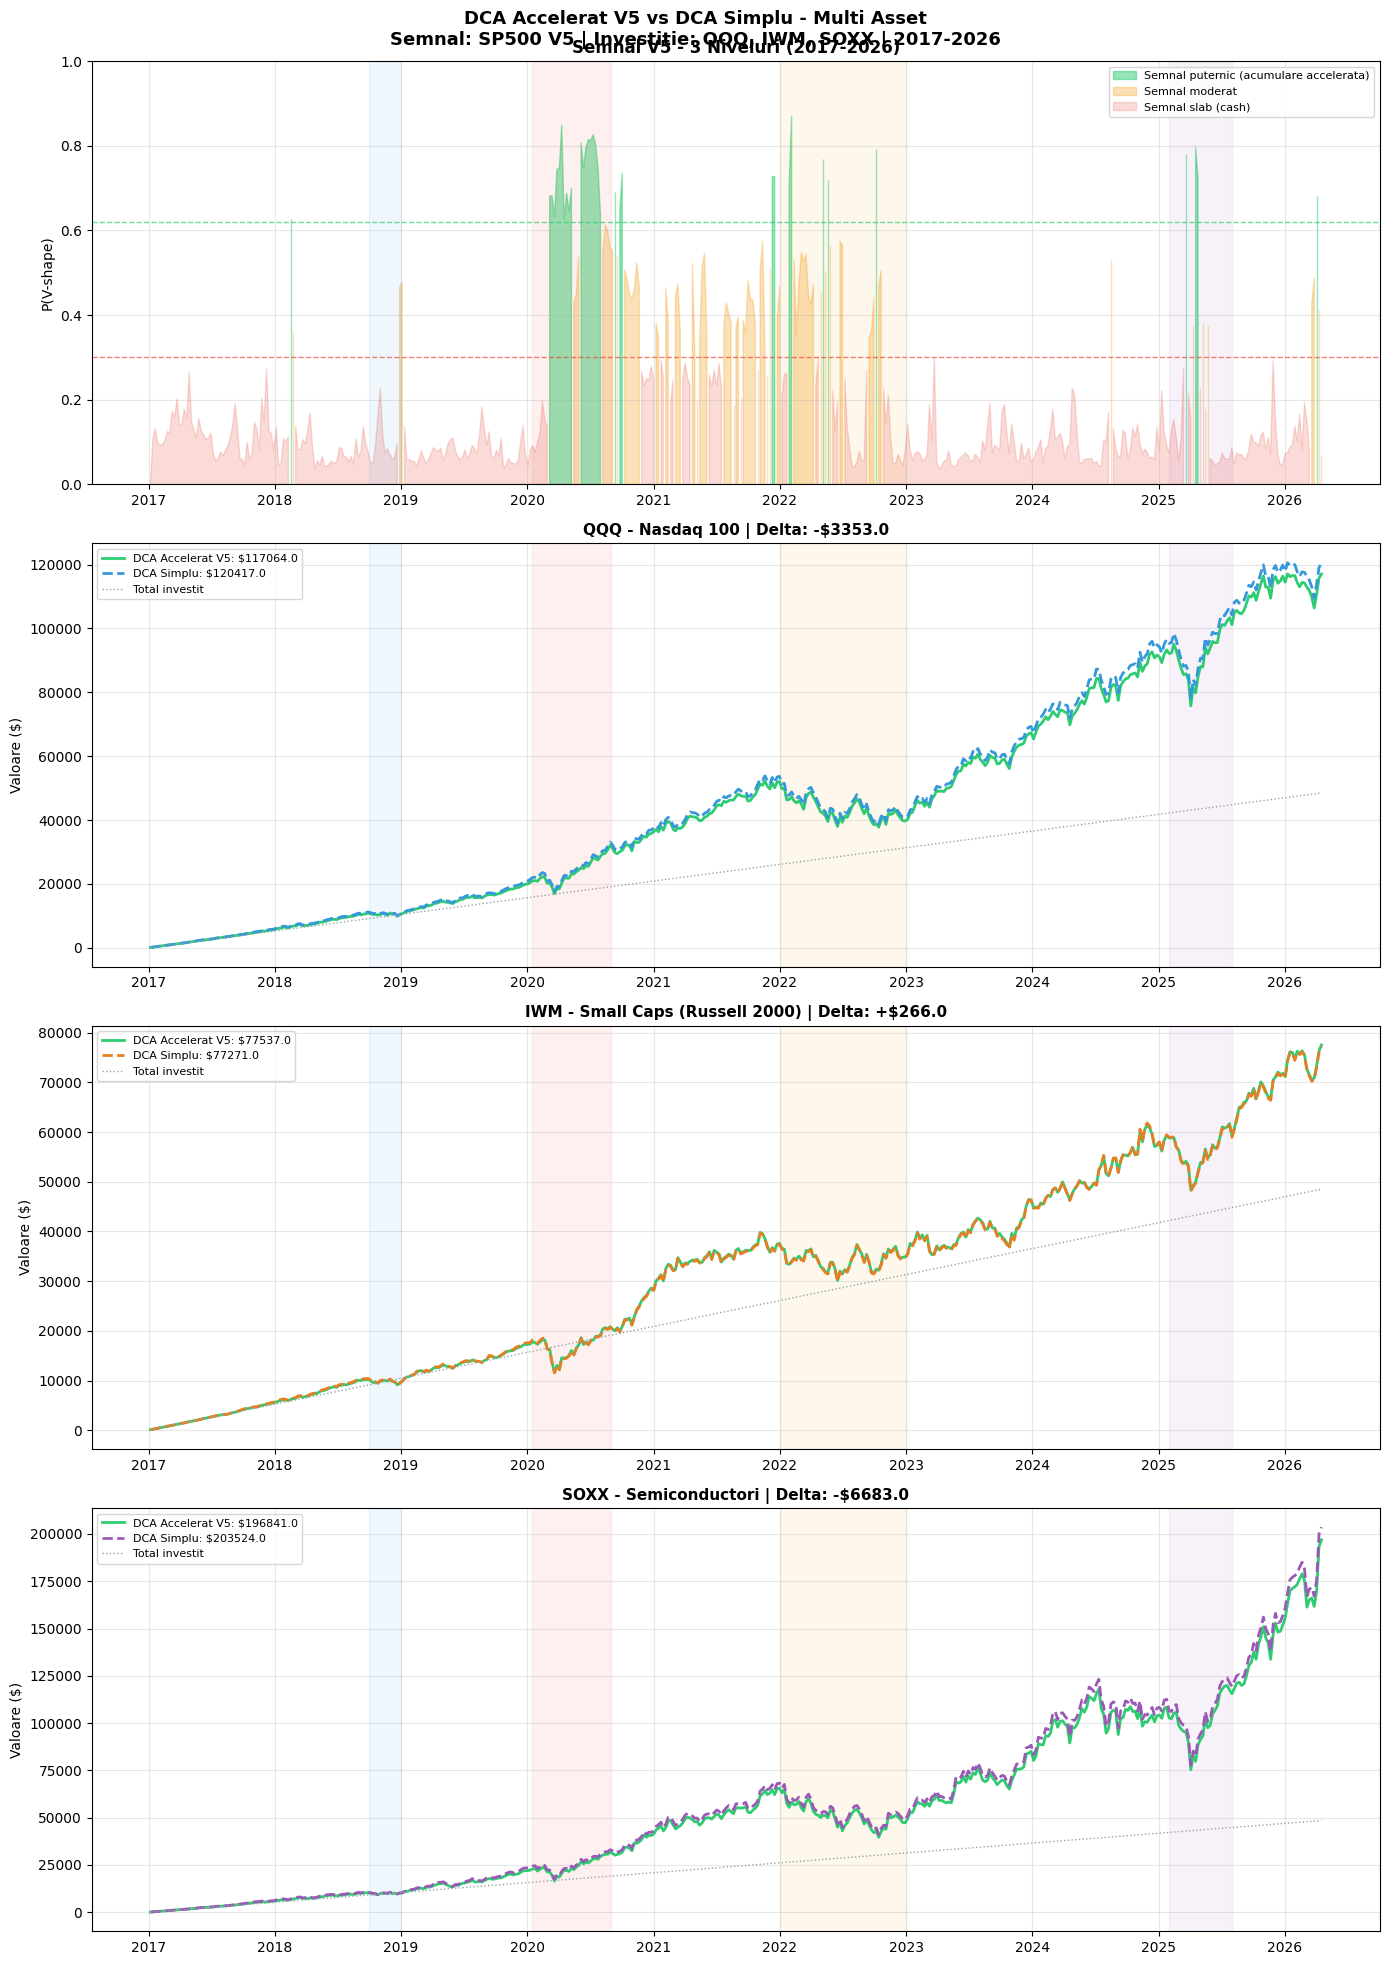

Salvat: plots/economic_v4_multiasset.png


In [20]:
crises = [
    {'name': 'Q4 2018',             'start': '2018-10-01', 'end': '2018-12-31', 'color': '#3498db'},
    {'name': 'COVID Crash',         'start': '2020-01-15', 'end': '2020-08-31', 'color': '#e74c3c'},
    {'name': 'Fed Rate Hikes 2022', 'start': '2022-01-01', 'end': '2022-12-31', 'color': '#f39c12'},
    {'name': 'Liberation Day 2025', 'start': '2025-02-01', 'end': '2025-08-01', 'color': '#9b59b6'},
]
colors_asset = {'QQQ': '#3498db', 'IWM': '#e67e22', 'SOXX': '#9b59b6'}

fig, axes = plt.subplots(len(ASSETS) + 1, 1, figsize=(14, 5 * (len(ASSETS) + 1)))

ax0 = axes[0]
ax0.fill_between(weekly_bt.index, proba_s, 0,
                 where=proba_s >= T_HIGH, alpha=0.5, color='#2ecc71',
                 label='Semnal puternic (acumulare accelerata)')
ax0.fill_between(weekly_bt.index, proba_s, 0,
                 where=(proba_s >= T_LOW) & (proba_s < T_HIGH),
                 alpha=0.3, color='#f39c12', label='Semnal moderat')
ax0.fill_between(weekly_bt.index, proba_s, 0,
                 where=proba_s < T_LOW, alpha=0.2, color='#e74c3c',
                 label='Semnal slab (cash)')
ax0.axhline(T_HIGH, color='#2ecc71', linestyle='--', linewidth=1, alpha=0.7)
ax0.axhline(T_LOW,  color='#e74c3c', linestyle='--', linewidth=1, alpha=0.7)
ax0.set_ylabel('P(V-shape)')
ax0.set_ylim(0, 1)
ax0.set_title('Semnal V5 - 3 Niveluri (2017-2026)', fontsize=12, fontweight='bold')
ax0.legend(loc='upper right', fontsize=8)
ax0.grid(True, alpha=0.3)
for c in crises:
    ax0.axvspan(pd.to_datetime(c['start']), pd.to_datetime(c['end']),
                alpha=0.08, color=c['color'])

for idx, (ticker, res) in enumerate(results_all.items()):
    ax  = axes[idx + 1]
    dca, acc = res['dca'], res['acc']
    col = colors_asset[ticker]

    ax.plot(acc['value_log'].index, acc['value_log'].values,
            color='#2ecc71', linewidth=2,
            label='DCA Accelerat V5: $' + str(round(acc['final_val'], 0)))
    ax.plot(dca['value_log'].index, dca['value_log'].values,
            color=col, linewidth=2, linestyle='--',
            label='DCA Simplu: $' + str(round(dca['final_val'], 0)))
    invested = pd.Series([WEEKLY_BUDGET*(i+1) for i in range(len(weekly_bt))],
                         index=weekly_bt.index)
    ax.plot(invested.index, invested.values, color='#95a5a6',
            linewidth=1, linestyle=':', label='Total investit')
    for c in crises:
        ax.axvspan(pd.to_datetime(c['start']), pd.to_datetime(c['end']),
                   alpha=0.08, color=c['color'])
    delta_val = round(acc['final_val'] - dca['final_val'], 0)
    delta_str = ('+$' if delta_val >= 0 else '-$') + str(abs(delta_val))
    ax.set_ylabel('Valoare ($)')
    ax.set_title(ticker + ' - ' + res['name'] + ' | Delta: ' + delta_str,
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('DCA Accelerat V5 vs DCA Simplu - Multi Asset\n' +
             'Semnal: SP500 V5 | Investitie: QQQ, IWM, SOXX | 2017-2026',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/economic_v4_multiasset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/economic_v4_multiasset.png')

## 8. Analiza per Criza

In [21]:
crisis_windows = [
    {'name': 'Q4 2018',             'start': '2018-10-01', 'end': '2019-06-30'},
    {'name': 'COVID Crash',         'start': '2020-01-15', 'end': '2020-12-31'},
    {'name': 'Fed Rate Hikes 2022', 'start': '2022-01-01', 'end': '2023-06-30'},
    {'name': 'Liberation Day 2025', 'start': '2025-02-01', 'end': '2026-04-14'},
]

print('ANALIZA PER CRIZA - Shares Acumulate vs DCA Simplu')
print('=' * 70)

for crisis in crisis_windows:
    mask     = (weekly_bt.index >= crisis['start']) & (weekly_bt.index <= crisis['end'])
    p_crisis = proba_s[mask]
    pct_acc  = round((p_crisis >= T_HIGH).mean() * 100, 1)
    print('\n' + crisis['name'] + ' | Saptamani accelerare: ' + str(pct_acc) + '%')
    print('-' * 50)

    for ticker in ASSETS:
        asset_weekly = asset_data[ticker].resample('W-FRI').last()
        asset_weekly = asset_weekly.reindex(weekly_bt.index, method='ffill')
        prices_c     = asset_weekly[mask]
        proba_c      = proba_s[mask]
        tbill_c      = tbill_w[mask.values]
        if len(prices_c) == 0:
            continue
        dca_c = run_dca(prices_c, proba_c, tbill_c, mode='simple')
        acc_c = run_dca(prices_c, proba_c, tbill_c, mode='accelerated')
        delta_shares = round(acc_c['shares'] - dca_c['shares'], 4)
        delta_cost   = round(dca_c['avg_cost'] - acc_c['avg_cost'], 2)
        sign = '+' if delta_shares >= 0 else ''
        print('  ' + ticker.ljust(6),
              '| DCA shares:', str(round(dca_c['shares'], 4)).rjust(8),
              '| ACC shares:', str(round(acc_c['shares'], 4)).rjust(8),
              '| Delta:', sign + str(delta_shares),
              '| Cost diff: $' + str(delta_cost))

ANALIZA PER CRIZA - Shares Acumulate vs DCA Simplu

Q4 2018 | Saptamani accelerare: 0.0%
--------------------------------------------------


AttributeError: 'numpy.ndarray' object has no attribute 'values'

## 9. Fraze pentru Paper

In [ ]:
separator = '=' * 65
print('FRAZE PENTRU PAPER')
print(separator)
print()
print('Economic Significance section:')
print('"We extend the analysis to higher-beta assets, using the V5')
print('Ensemble signal on S&P 500 as a market-wide recovery detector')
print('while allocating capital to Nasdaq 100 (QQQ), Russell 2000 (IWM),')
print('and Semiconductors (SOXX) over the January 2017 - April 2026 period.')
print()
print('An investor allocating $' + str(WEEKLY_BUDGET) + '/week ($' + str(BASE_INVEST) + ' base + $' + str(CASH_SAVE) + ' conditional)')
print('deployed using the three-tier V5 signal achieves:')
print()
for ticker, res in results_all.items():
    dca, acc = res['dca'], res['acc']
    dc = round(dca['avg_cost'] - acc['avg_cost'], 2)
    dv = round(acc['final_val'] - dca['final_val'], 0)
    sign_c = '+' if dc >= 0 else ''
    sign_v = '+' if dv >= 0 else ''
    print(ticker + ' (' + res['name'] + '):')
    print('  Average cost per share: $' + str(round(acc['avg_cost'],2)) +
          ' vs $' + str(round(dca['avg_cost'],2)) +
          ' (' + sign_c + str(dc) + ')')
    print('  Portfolio value delta: ' + sign_v + '$' + str(dv))
    print()